# 05 — Trial forecast diagnostic (june-composite style)

Plot actuals + the hybrid trial forecast + a no-marketing-lift baseline, in the same visual style as `data-official/2026-06/june_composite_forecast.ipynb:[plot-mobile]`.

**Headwinds:** applied to both forecast lines via `data-official/2026-06/adjustments/headwind.json` (linear ramp 2026-04-01 → 2026-12-15, mobile reaches −27,162 DAU at Dec-15). This matches the production-composite style. Title and legend make this explicit.

**Scope:** mobile (Fenix + iOS + Focus), ex-Iran on both actuals and forecasts (since the trial was run without Iran add-back). All series at country=ALL, app_name='ALL MOBILE', segment='{}', data_source='glean_mobile'.

**Series:**
1. **Actuals** — BQ `glean_telemetry.active_users_aggregates`, excluding `country='IR'`. 28d MA.
2. **Hybrid trial** — `tmp/hybrid_trial_2026-05-17/mozaic_daily_forecast.2026-05-17.gm-D.parquet` (m-adjustment applied via the hybrid lift series), + headwinds applied to the MA.
3. **No-marketing-lift baseline** — `data-official/2026-06/mobile_cps0.02_thresh32_recent13_clip0.6_cap426/mozaic_daily_forecast.2026-05-17.gm-D.raw.parquet` (no adjustments at all from mozaic), + headwinds applied to the MA.


In [1]:
# [setup]
import glob
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from google.cloud import bigquery

REPO_ROOT = Path('/Users/brendanwells/work/mozaic-daily')
TRIAL_HYBRID_PATH = REPO_ROOT / 'tmp/hybrid_trial_2026-05-17/mozaic_daily_forecast.2026-05-17.gm-D.parquet'
NO_MKTG_RAW_PATH = REPO_ROOT / 'data-official/2026-06/mobile_cps0.02_thresh32_recent13_clip0.6_cap426/mozaic_daily_forecast.2026-05-17.gm-D.raw.parquet'
APRIL_FORECAST_PATH = REPO_ROOT / 'data-official/2026-04/mobile_cps0.02_thresh32_recent13_clip0.6/mozaic_daily_forecast.2026-04-01.gm-D.raw.parquet'
ADJUSTMENTS_DIR = REPO_ROOT / 'data-official/2026-06/adjustments'

# Dates
DISPLAY_START = pd.Timestamp("2026-01-01")
DISPLAY_END = pd.Timestamp("2026-12-31")
FORECAST_START = pd.Timestamp("2026-05-17")
PREV_FORECAST_START = pd.Timestamp("2026-04-01")  # April forecast start; headwinds apply from here for N-1
MEASUREMENT_DATE = pd.Timestamp("2026-12-15")
BQ_START = "2025-12-04"  # need 28d before DISPLAY_START for the MA


def millions_formatter(x, pos):
    return f"{x / 1e6:.1f}M"


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


In [2]:
# [helpers]
# Copied verbatim from data-official/2026-06/june_composite_forecast.ipynb:[helpers]


def render_adjustment(spec, date_index):
    idx = pd.DatetimeIndex(date_index)
    desktop = pd.Series(0.0, index=idx)
    mobile = pd.Series(0.0, index=idx)
    if spec["type"] == "linear_ramp":
        start = pd.Timestamp(spec["start_date"])
        anchor = pd.Timestamp(spec["anchor_date"])
        total_days = (anchor - start).days
        elapsed = np.maximum(0, (idx - start).days)
        desktop[:] = spec.get("desktop_dau", 0) * elapsed / total_days
        mobile[:] = spec.get("mobile_dau", 0) * elapsed / total_days
    elif spec["type"] == "step":
        start = pd.Timestamp(spec["start_date"])
        end = pd.Timestamp(spec["end_date"]) if "end_date" in spec else idx[-1]
        mask = (idx >= start) & (idx <= end)
        desktop[mask] = spec.get("desktop_dau", 0)
        mobile[mask] = spec.get("mobile_dau", 0)
    elif spec["type"] == "daily_series":
        for date_str, values in spec["series"].items():
            date = pd.Timestamp(date_str)
            if date in idx:
                loc = idx.get_loc(date)
                desktop.iloc[loc] = values.get("desktop_dau", 0)
                mobile.iloc[loc] = values.get("mobile_dau", 0)
    return {"desktop": desktop, "mobile": mobile}


def load_adjustments(adjustments_dir, date_index):
    idx = pd.DatetimeIndex(date_index)
    desktop_total = pd.Series(0.0, index=idx)
    mobile_total = pd.Series(0.0, index=idx)
    for path in sorted(glob.glob(f"{adjustments_dir}/*.json")):
        with open(path) as f:
            spec = json.load(f)
        rendered = render_adjustment(spec, idx)
        desktop_total += rendered["desktop"]
        mobile_total += rendered["mobile"]
    return {"desktop": desktop_total, "mobile": mobile_total}


def apply_net_adjustment(ma_series, net_adjustments, platform, forecast_start=None):
    if forecast_start is None:
        forecast_start = FORECAST_START
    result = ma_series.copy()
    forecast_mask = result.index >= forecast_start
    adj = net_adjustments[platform].reindex(result.index, fill_value=0.0)
    result[forecast_mask] += adj[forecast_mask]
    return result


def load_all_level_dau(path, data_source, segment_filter, app_filter):
    df = pd.read_parquet(path)
    mask = (
        (df["country"] == "ALL")
        & (df["segment"] == segment_filter)
        & (df["data_source"] == data_source)
        & (df["app_name"] == app_filter)
    )
    result = df.loc[mask, ["target_date", "dau", "data_type"]].copy()
    result["target_date"] = pd.to_datetime(result["target_date"])
    return result.sort_values("target_date").reset_index(drop=True)


def daily_to_28ma(dates, values):
    s = pd.Series(values.values, index=pd.to_datetime(dates.values))
    return s.sort_index().rolling(28).mean()


def clip_display(s):
    return s[(s.index >= DISPLAY_START) & (s.index <= DISPLAY_END)]


def clip_forecast_only(s):
    return s[(s.index >= FORECAST_START) & (s.index <= DISPLAY_END)]


In [3]:
# [load-parquets]
hybrid_raw = load_all_level_dau(TRIAL_HYBRID_PATH, "glean_mobile", "{}", "ALL MOBILE")
no_mktg_raw = load_all_level_dau(NO_MKTG_RAW_PATH, "glean_mobile", "{}", "ALL MOBILE")
april_raw = load_all_level_dau(APRIL_FORECAST_PATH, "glean_mobile", "{}", "ALL MOBILE")

print(f'Trial hybrid (with m-adjustment via hybrid lift series, no Iran add-back):')
print(f'  rows: {len(hybrid_raw)}, dates: {hybrid_raw["target_date"].min().date()} → {hybrid_raw["target_date"].max().date()}')
print(f'No-marketing-lift raw (no m, no h, no Iran add-back):')
print(f'  rows: {len(no_mktg_raw)}, dates: {no_mktg_raw["target_date"].min().date()} → {no_mktg_raw["target_date"].max().date()}')
print(f'April forecast (N-1, no m, no h, no Iran add-back):')
print(f'  rows: {len(april_raw)}, dates: {april_raw["target_date"].min().date()} → {april_raw["target_date"].max().date()}')


Trial hybrid (with m-adjustment via hybrid lift series, no Iran add-back):
  rows: 2557, dates: 2020-12-31 → 2027-12-31
No-marketing-lift raw (no m, no h, no Iran add-back):
  rows: 2557, dates: 2020-12-31 → 2027-12-31
April forecast (N-1, no m, no h, no Iran add-back):
  rows: 2557, dates: 2020-12-31 → 2027-12-31


In [4]:
# [bq-actuals]
# Same query as data-official/2026-06/june_composite_forecast.ipynb:[bq-actuals]
import sys, time

client = bigquery.Client(project="moz-fx-data-bq-data-science")

sql = f"""
    SELECT submission_date AS date, SUM(dau) AS dau
    FROM `moz-fx-data-shared-prod.glean_telemetry.active_users_aggregates`
    WHERE app_name IN ("Fenix", "Firefox iOS", "Focus Android", "Focus iOS")
      AND submission_date BETWEEN '{BQ_START}' AND CURRENT_DATE() - 1
      AND country != 'IR'
    GROUP BY submission_date ORDER BY 1
"""
t0 = time.time()
sys.stdout.write('Querying mobile actuals (ex-Iran)...')
sys.stdout.flush()
mobile_actuals_raw = client.query(sql).to_dataframe()
mobile_actuals_raw['date'] = pd.to_datetime(mobile_actuals_raw['date'])
sys.stdout.write(f' {len(mobile_actuals_raw)} rows ({time.time() - t0:.1f}s)\n')
print(f'Date range: {mobile_actuals_raw["date"].min().date()} → {mobile_actuals_raw["date"].max().date()}')


Querying mobile actuals (ex-Iran)...

 166 rows (7.3s)
Date range: 2025-12-04 → 2026-05-18


In [5]:
# [compute-series]
# 28-day MAs
hybrid_ma_raw = daily_to_28ma(hybrid_raw['target_date'], hybrid_raw['dau'])
no_mktg_ma_raw = daily_to_28ma(no_mktg_raw['target_date'], no_mktg_raw['dau'])
april_ma_raw = daily_to_28ma(april_raw['target_date'], april_raw['dau'])
actuals_ma = daily_to_28ma(mobile_actuals_raw['date'], mobile_actuals_raw['dau'])

# Apply headwinds via the production helper
net_adjustments = load_adjustments(str(ADJUSTMENTS_DIR), hybrid_ma_raw.index)
hybrid_ma_h = apply_net_adjustment(hybrid_ma_raw, net_adjustments, 'mobile')
no_mktg_ma_h = apply_net_adjustment(no_mktg_ma_raw, net_adjustments, 'mobile')
# April forecast: headwinds anchored at PREV_FORECAST_START so the adjustment applies
# from when that forecast's predicted data begins (per feedback memory on N-1 comparisons).
april_ma_h = apply_net_adjustment(april_ma_raw, net_adjustments, 'mobile',
                                  forecast_start=PREV_FORECAST_START)

# Diagnostic: report adjustments at MEASUREMENT_DATE
print(f'Headwind net adjustment at {MEASUREMENT_DATE.date()}:')
print(f'  mobile DAU adjustment: {net_adjustments["mobile"].loc[MEASUREMENT_DATE]:+,.0f}')
print()
print(f'Dec-15 28d-MA values:')
if MEASUREMENT_DATE in actuals_ma.index:
    print(f'  Actuals (ex-Iran, observed):                              {actuals_ma.loc[MEASUREMENT_DATE]:>+15,.0f}')
else:
    print(f'  Actuals @ Dec-15: not yet observed')
print(f'  April forecast (N-1, no m) + headwinds:                       {april_ma_h.loc[MEASUREMENT_DATE]:>+15,.0f}')
print(f'  Hybrid trial (m applied) + headwinds:                         {hybrid_ma_h.loc[MEASUREMENT_DATE]:>+15,.0f}')
print(f'  No-marketing-lift baseline (raw) + headwinds:                 {no_mktg_ma_h.loc[MEASUREMENT_DATE]:>+15,.0f}')
print(f'  April forecast (no headwinds):                                {april_ma_raw.loc[MEASUREMENT_DATE]:>+15,.0f}')
print(f'  Hybrid (no headwinds):                                        {hybrid_ma_raw.loc[MEASUREMENT_DATE]:>+15,.0f}')
print(f'  No-marketing-lift baseline (no headwinds):                    {no_mktg_ma_raw.loc[MEASUREMENT_DATE]:>+15,.0f}')


Headwind net adjustment at 2026-12-15:
  mobile DAU adjustment: -27,162

Dec-15 28d-MA values:
  Actuals @ Dec-15: not yet observed
  April forecast (N-1, no m) + headwinds:                           +16,389,749
  Hybrid trial (m applied) + headwinds:                             +17,063,287
  No-marketing-lift baseline (raw) + headwinds:                     +16,499,813
  April forecast (no headwinds):                                    +16,416,911
  Hybrid (no headwinds):                                            +17,090,449
  No-marketing-lift baseline (no headwinds):                        +16,526,975


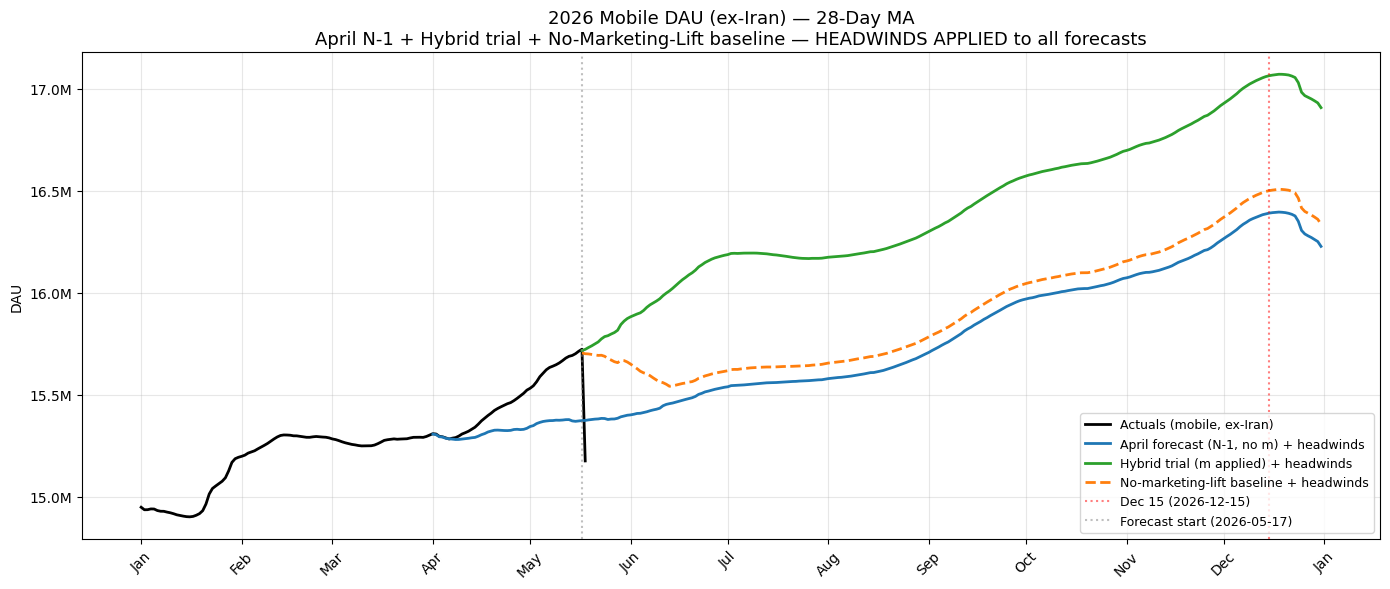

In [6]:
# [plot-mobile]
# June-composite-style mobile DAU plot. Both forecast lines have headwinds applied.

fig, ax = plt.subplots(figsize=(14, 6))

# Actuals (bold)
ax.plot(clip_display(actuals_ma), label='Actuals (mobile, ex-Iran)',
        color='black', linewidth=2)

# April forecast (N-1) — blue, matches june_composite_forecast.ipynb style
april_clip = clip_display(april_ma_h)
ax.plot(april_clip[april_clip.index >= PREV_FORECAST_START],
        label='April forecast (N-1, no m) + headwinds',
        color='C0', linewidth=2)

# Hybrid trial — green
ax.plot(clip_forecast_only(hybrid_ma_h),
        label='Hybrid trial (m applied) + headwinds',
        color='C2', linewidth=2)

# No-marketing-lift baseline — orange
ax.plot(clip_forecast_only(no_mktg_ma_h),
        label='No-marketing-lift baseline + headwinds',
        color='C1', linewidth=2, linestyle='--')

ax.axvline(MEASUREMENT_DATE, color='red', linestyle=':', alpha=0.5,
           label=f'Dec 15 ({MEASUREMENT_DATE.date()})')
ax.axvline(FORECAST_START, color='gray', linestyle=':', alpha=0.5,
           label=f'Forecast start ({FORECAST_START.date()})')

ax.set_title('2026 Mobile DAU (ex-Iran) — 28-Day MA\n'
             'April N-1 + Hybrid trial + No-Marketing-Lift baseline — HEADWINDS APPLIED to all forecasts',
             fontsize=13)
ax.set_ylabel('DAU')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.legend(loc='lower right', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


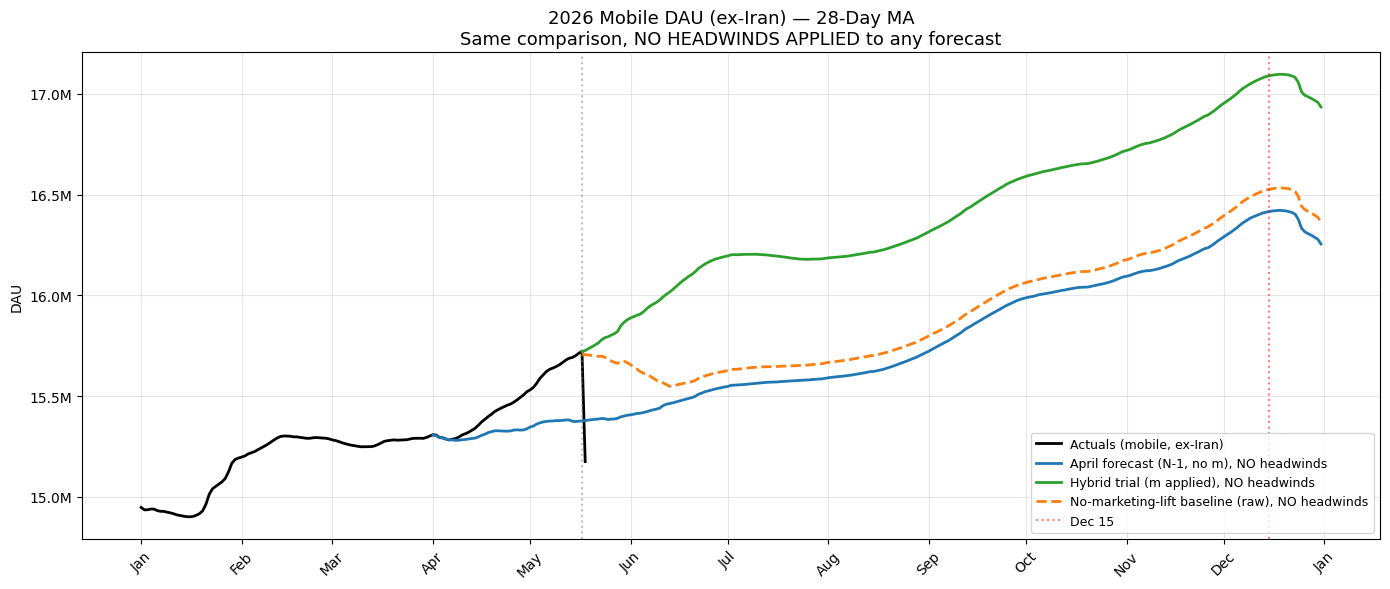

In [7]:
# [plot-mobile-no-headwinds]
# Variant: same comparison without headwinds. Useful to isolate the marketing-lift effect.

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(clip_display(actuals_ma), label='Actuals (mobile, ex-Iran)',
        color='black', linewidth=2)

april_clip = clip_display(april_ma_raw)
ax.plot(april_clip[april_clip.index >= PREV_FORECAST_START],
        label='April forecast (N-1, no m), NO headwinds',
        color='C0', linewidth=2)
ax.plot(clip_forecast_only(hybrid_ma_raw),
        label='Hybrid trial (m applied), NO headwinds',
        color='C2', linewidth=2)
ax.plot(clip_forecast_only(no_mktg_ma_raw),
        label='No-marketing-lift baseline (raw), NO headwinds',
        color='C1', linewidth=2, linestyle='--')

ax.axvline(MEASUREMENT_DATE, color='red', linestyle=':', alpha=0.5,
           label=f'Dec 15')
ax.axvline(FORECAST_START, color='gray', linestyle=':', alpha=0.5)

ax.set_title('2026 Mobile DAU (ex-Iran) — 28-Day MA\n'
             'Same comparison, NO HEADWINDS APPLIED to any forecast',
             fontsize=13)
ax.set_ylabel('DAU')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.legend(loc='lower right', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
